# Step 1 — Data loading & initial exploration
Load the classification dataset (`student_performance_grade.csv`) and inspect its shape, types, missing values, and the grade distribution to establish a baseline understanding.

In [13]:
# ============================================================
# STEP 1: Data Loading & Initial Exploration
# ============================================================
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Avoid loky/joblib WMIC warning on Windows (first run)
if "LOKY_MAX_CPU_COUNT" not in os.environ:
    os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count() or 1)

# --- Load the classification file ---
df_grade = pd.read_csv('student_performance_grade.csv')

print("=== CLASSIFICATION DATASET (Grade) ===")
print(f"Shape: {df_grade.shape}")
print(df_grade.head())

# --- Basic info ---
print("\n--- Data Types ---")
print(df_grade.dtypes)

print("\n--- Missing Values ---")
print(df_grade.isnull().sum())

print("\n--- Numerical Summary ---")
print(df_grade.describe())

print("\n--- Categorical Columns ---")
cat_cols = ['Gender','Study_Method','Diet_Quality','Internet_Quality',
            'Family_Income_Level','Part_Time_Job','Extracurricular']
for col in cat_cols:
    print(f"\n{col}:\n{df_grade[col].value_counts()}")

# --- Grade distribution (classification) ---
print("\n--- Grade Distribution ---")
print(df_grade['Grade'].value_counts())
print(df_grade['Grade'].value_counts(normalize=True).round(3) * 100, "(%)")

=== CLASSIFICATION DATASET (Grade) ===
Shape: (8000, 18)
  Student_ID  Age  Gender  Hours_Studied  Attendance  Sleep_Hours  \
0   STU00001   17  Female           8.20        80.0          7.3   
1   STU00002   22    Male           4.07        69.2          7.9   
2   STU00003   23  Female           5.07        74.2          6.7   
3   STU00004   22  Female           5.82        82.5          3.7   
4   STU00005   21    Male           3.42        90.8          7.4   

   Stress_Level  Screen_Time  Previous_GPA Part_Time_Job Study_Method  \
0           2.3          3.2          3.07            No       Online   
1           3.6          0.5          2.66           Yes      Offline   
2           2.6          4.7          3.27            No       Hybrid   
3           3.3          2.3          2.87            No      Offline   
4           7.0          3.1          2.82           Yes      Offline   

  Diet_Quality Internet_Quality Extracurricular  Tutoring_Sessions_Per_Week  \
0      Ave

# Step 2 — Exploratory data analysis
Visualize class balance, numerical distributions, correlations, and how grades relate to key features. This helps surface patterns and potential predictors before modeling.

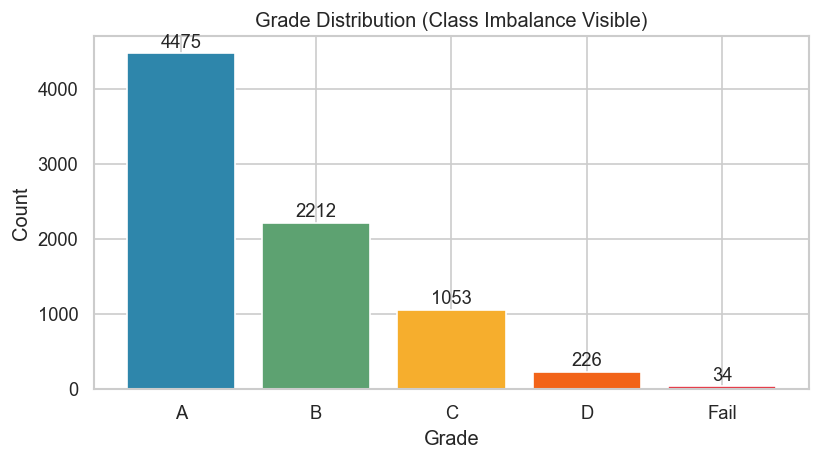

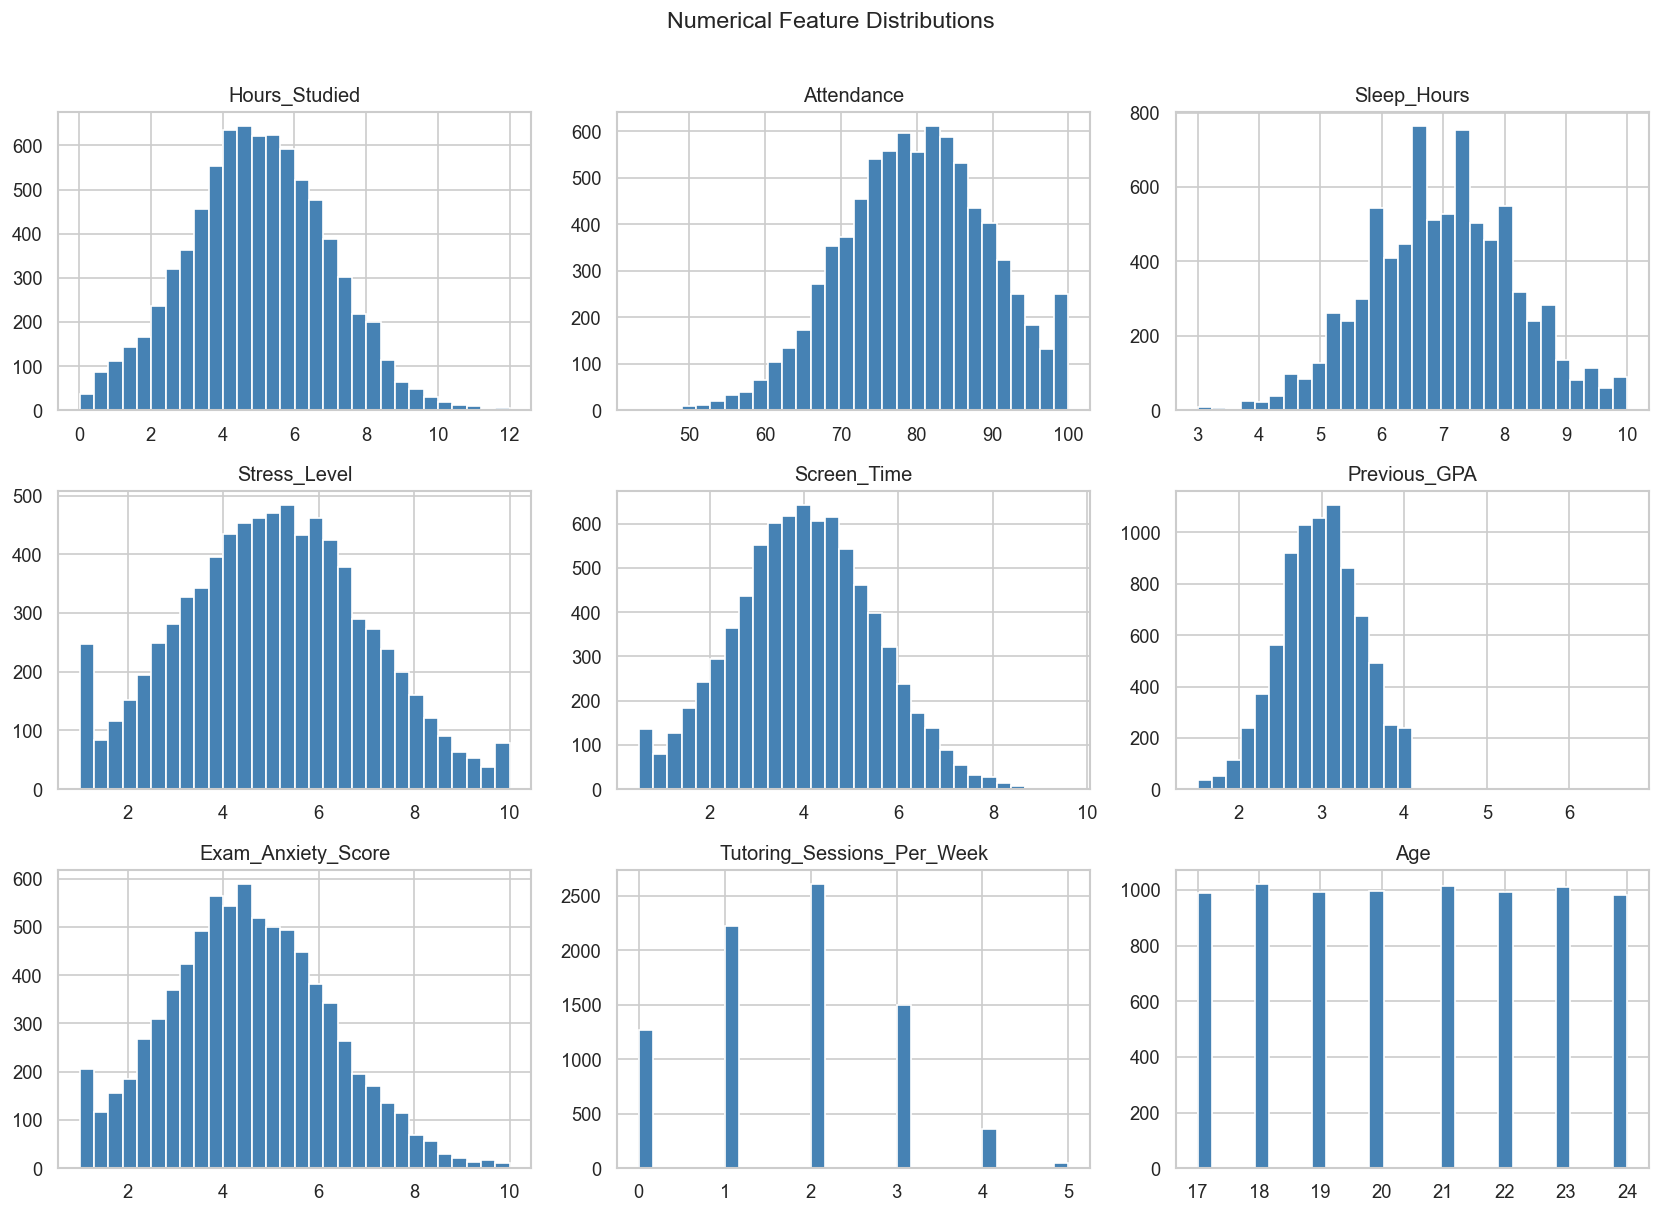

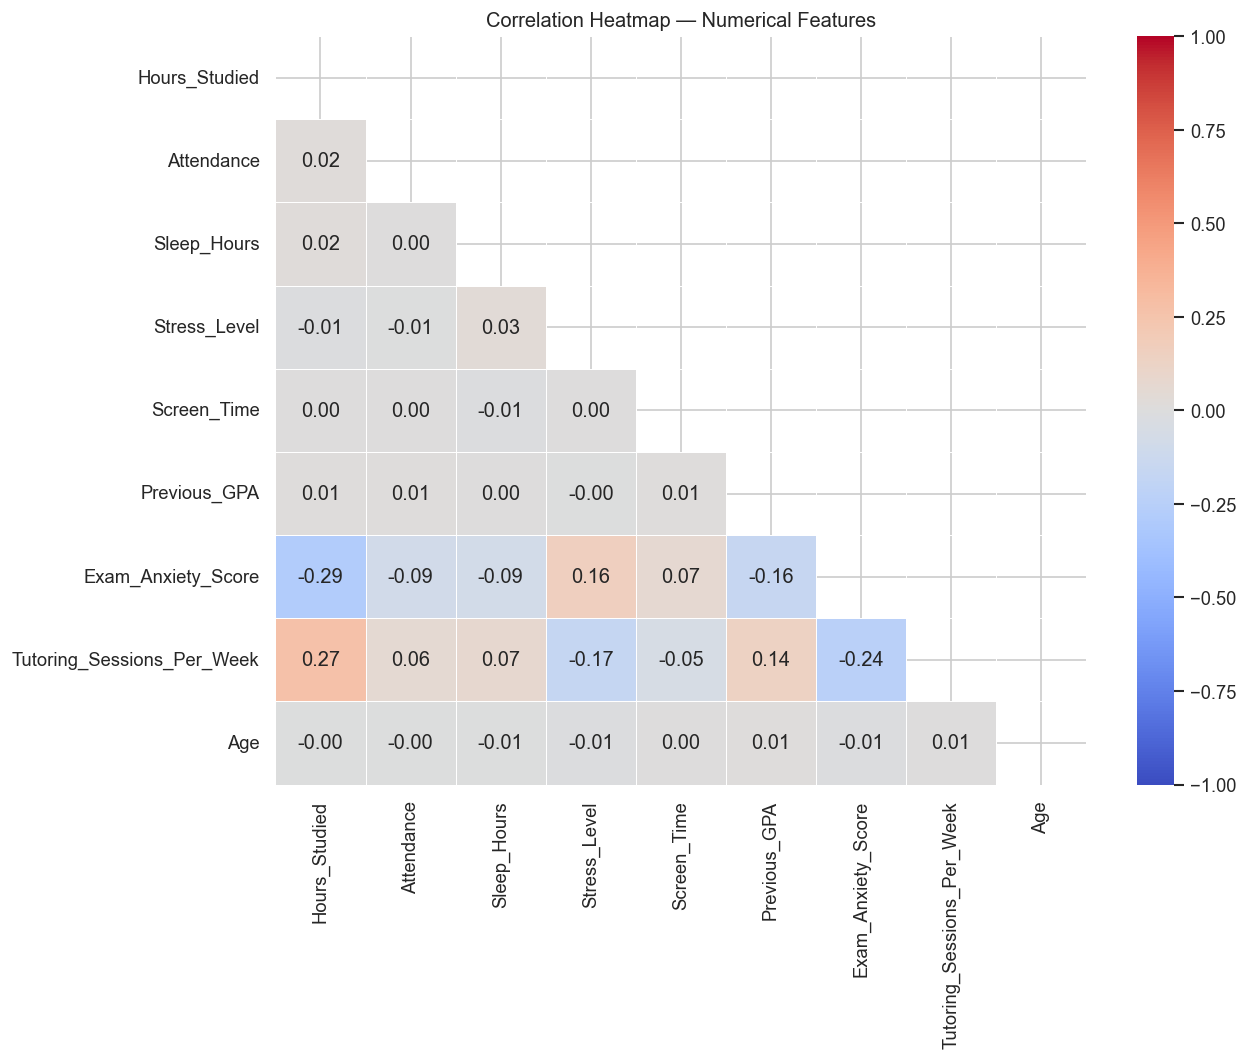

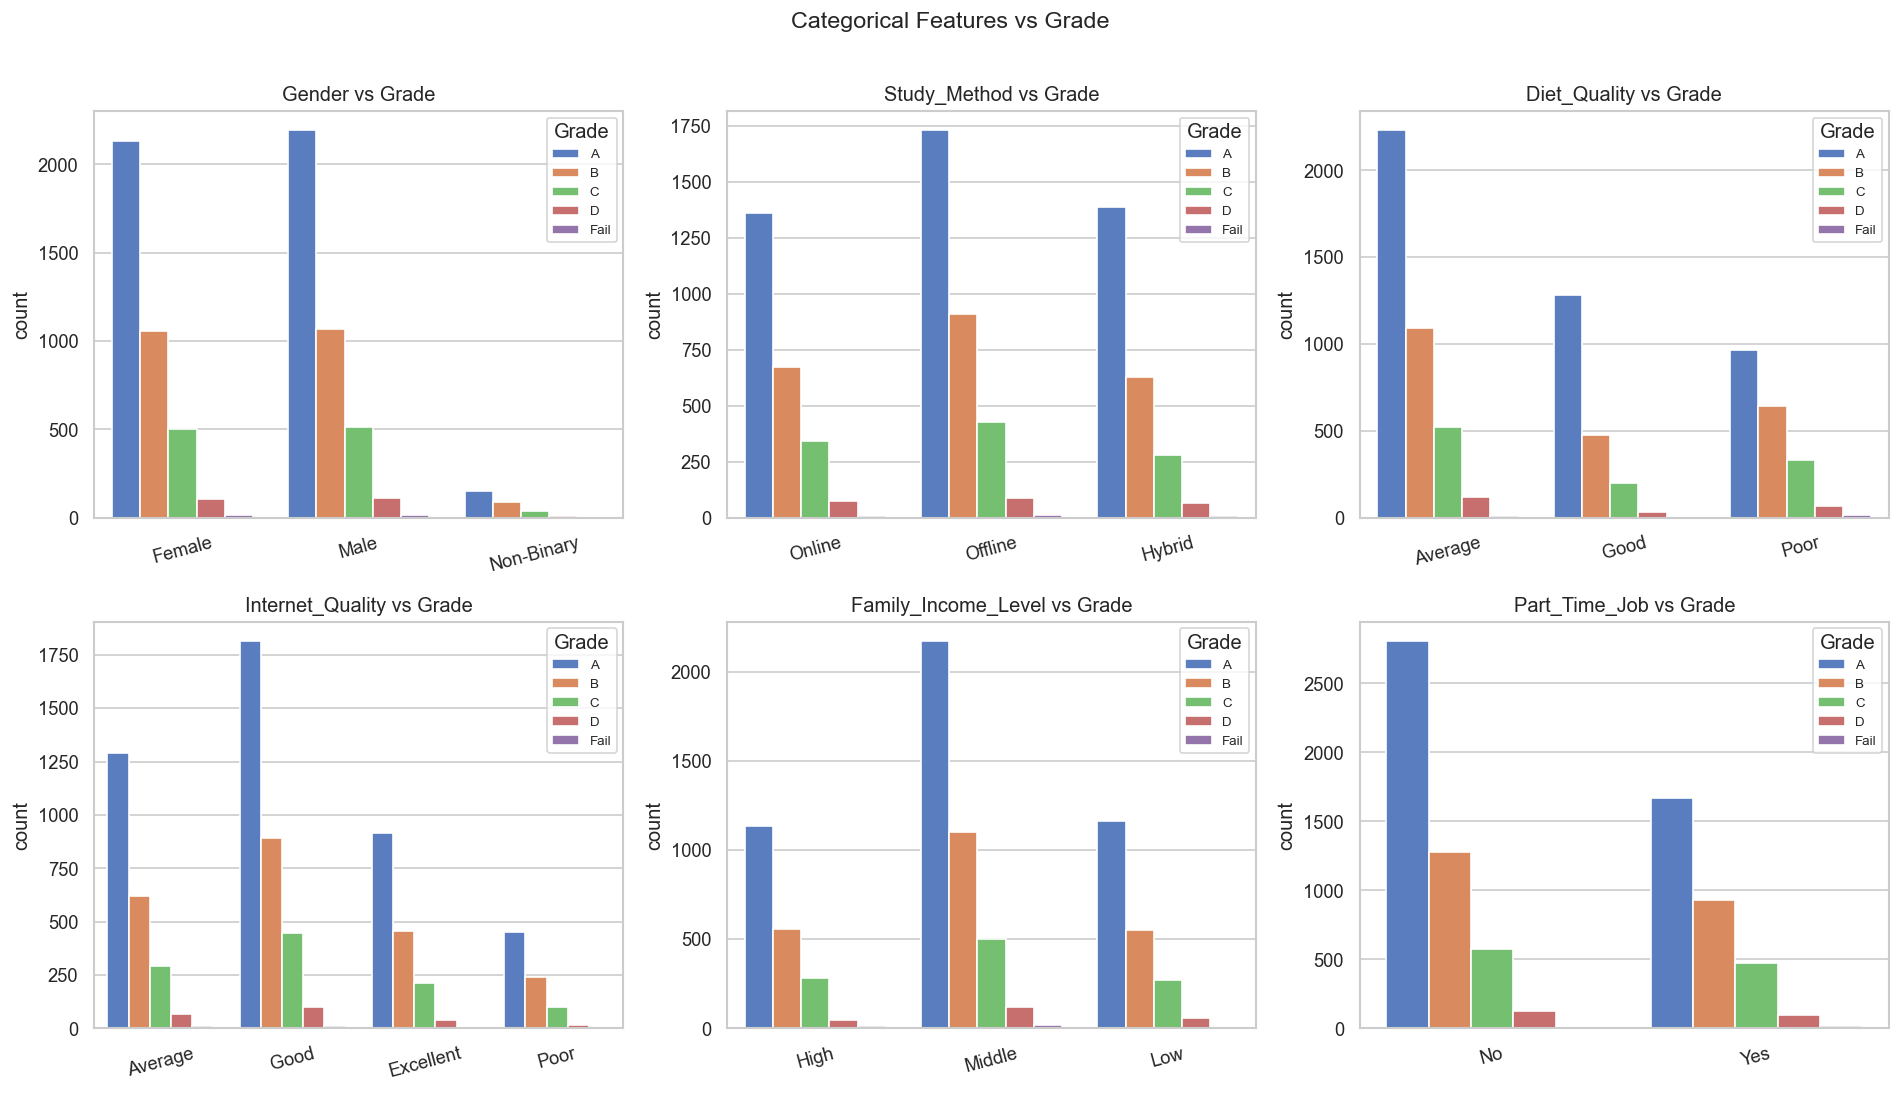

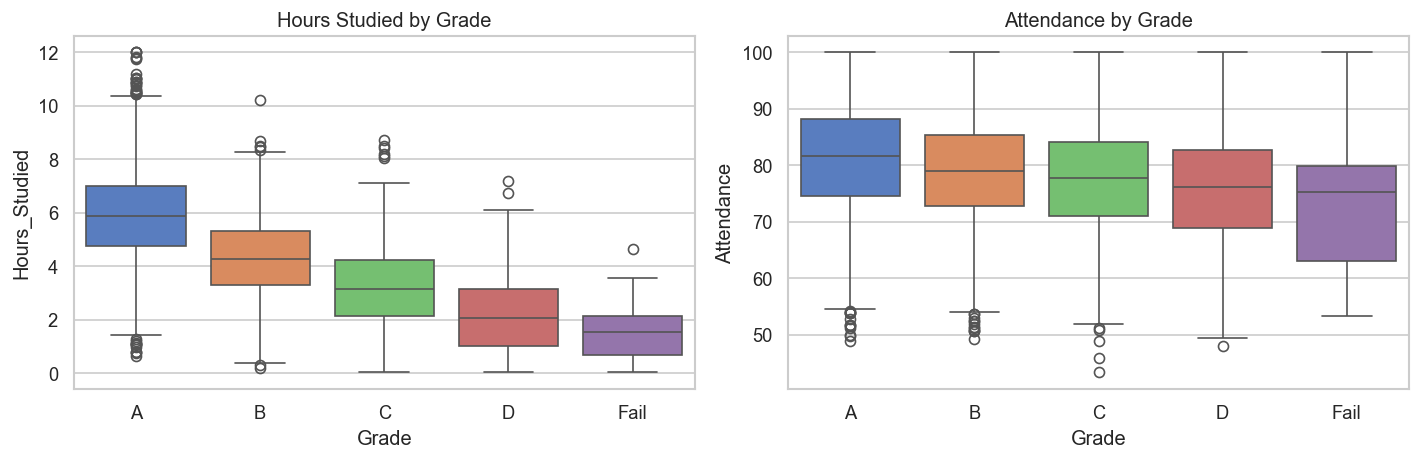

All EDA plots saved!


In [14]:
# ============================================================
# STEP 2: Exploratory Data Analysis (EDA)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set global style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# ----------------------------------------------------------
# 2.2  Grade class imbalance (classification target)
# ----------------------------------------------------------
grade_order = ['A', 'B', 'C', 'D', 'Fail']
grade_counts = df_grade['Grade'].value_counts().reindex(grade_order)

plt.figure(figsize=(7, 4))
bars = plt.bar(grade_counts.index, grade_counts.values,
               color=['#2e86ab','#5da271','#f6ae2d','#f26419','#e63946'])
for bar, val in zip(bars, grade_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(val), ha='center', va='bottom', fontsize=11)
plt.title('Grade Distribution (Class Imbalance Visible)')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('eda_grade_dist.png')
plt.show()

# ----------------------------------------------------------
# 2.3  Numerical feature distributions
# ----------------------------------------------------------
num_cols = ['Hours_Studied','Attendance','Sleep_Hours','Stress_Level',
            'Screen_Time','Previous_GPA','Exam_Anxiety_Score',
            'Tutoring_Sessions_Per_Week','Age']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df_grade[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.suptitle('Numerical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_num_distributions.png')
plt.show()

# ----------------------------------------------------------
# 2.4  Correlation heatmap (numerical features)
# ----------------------------------------------------------
corr_cols = num_cols + (['Final_Score'] if 'Final_Score' in df_grade.columns else [])
corr_df = df_grade[corr_cols].corr()

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png')
plt.show()

# ----------------------------------------------------------
# 2.6  Categorical features vs Grade (count plots)
# ----------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols[:6]):
    grade_order_plot = ['A', 'B', 'C', 'D', 'Fail']
    sns.countplot(data=df_grade, x=col, hue='Grade',
                  hue_order=grade_order_plot, ax=axes[i], palette='muted')
    axes[i].set_title(f'{col} vs Grade')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].legend(title='Grade', fontsize=8)
plt.suptitle('Categorical Features vs Grade', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_categorical_vs_grade.png')
plt.show()

# ----------------------------------------------------------
# 2.7  Grade vs key features
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df_grade, x='Grade', y='Hours_Studied',
            order=grade_order, ax=axes[0], palette='muted')
axes[0].set_title('Hours Studied by Grade')

sns.boxplot(data=df_grade, x='Grade', y='Attendance',
            order=grade_order, ax=axes[1], palette='muted')
axes[1].set_title('Attendance by Grade')
plt.tight_layout()
plt.savefig('eda_grade_vs_features.png')
plt.show()

print("All EDA plots saved!")

# Step 3 — Data preprocessing
Prepare features for classification by encoding ordered categories with `OrdinalEncoder`, nominal categories with one-hot encoding, and balancing classes with SMOTE to reduce bias toward majority grades.

In [15]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "16"  # put your real core count
# ============================================================
# STEP 3: Data Preprocessing (Classification Only)
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE   # pip install imbalanced-learn

# ----------------------------------------------------------
# 3.1  Define feature columns by type
# ----------------------------------------------------------

# Drop rows with missing target (Grade) to avoid stratify errors
df_grade = df_grade.dropna(subset=['Grade']).copy()

# Drop Student_ID — it is not a feature (ignore if not present)
df_grade = df_grade.drop(columns=['Student_ID'], errors='ignore')

# Ordinal categoricals — have a meaningful order
ordinal_cols = ['Diet_Quality', 'Internet_Quality', 'Family_Income_Level']
ordinal_orders = [
    ['Poor', 'Average', 'Good'],                  # Diet_Quality
    ['Poor', 'Average', 'Good', 'Excellent'],      # Internet_Quality
    ['Low', 'Middle', 'High'],                     # Family_Income_Level
]

# Nominal categoricals — no natural order
nominal_cols = ['Gender', 'Study_Method']

# Binary — Yes/No
binary_cols = ['Part_Time_Job', 'Extracurricular']
binary_orders = [['No', 'Yes'], ['No', 'Yes']]

# Numerical
num_cols = ['Age', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Stress_Level',
            'Screen_Time', 'Previous_GPA', 'Exam_Anxiety_Score',
            'Tutoring_Sessions_Per_Week']

# ----------------------------------------------------------
# 3.3  Build the preprocessing pipeline (ColumnTransformer)
#      (includes imputers to handle any missing values)
# ----------------------------------------------------------
preprocessor_clf = ColumnTransformer(transformers=[
    # Scale numerical features
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), num_cols),

    # Ordinal encode with correct order
    ('ord', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(categories=ordinal_orders)),
    ]), ordinal_cols),

    # One-hot encode nominal (drop first to avoid multicollinearity)
    ('nom', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')),
    ]), nominal_cols),

    # Binary columns encoded inside the pipeline
    ('bin', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(categories=binary_orders)),
    ]), binary_cols),
])

# ----------------------------------------------------------
# 3.4  CLASSIFICATION DATASET — split, transform, handle imbalance
# ----------------------------------------------------------
X_clf = df_grade.drop(columns=['Grade'])
y_clf = df_grade['Grade']

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42,
    stratify=y_clf          # keeps class proportions in both splits
)

X_clf_train_t = preprocessor_clf.fit_transform(X_clf_train)
X_clf_test_t  = preprocessor_clf.transform(X_clf_test)

print(f"Classification — Before SMOTE: {X_clf_train_t.shape}")
print("Class distribution before SMOTE:")
print(y_clf_train.value_counts())

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42, k_neighbors=3)
X_clf_train_sm, y_clf_train_sm = smote.fit_resample(X_clf_train_t, y_clf_train)

print(f"\nAfter SMOTE: {X_clf_train_sm.shape}")
print("Class distribution after SMOTE:")
print(pd.Series(y_clf_train_sm).value_counts())

Classification — Before SMOTE: (6400, 18)
Class distribution before SMOTE:
Grade
A       3580
B       1770
C        842
D        181
Fail      27
Name: count, dtype: int64

After SMOTE: (17900, 18)
Class distribution after SMOTE:
Grade
B       3580
A       3580
D       3580
C       3580
Fail    3580
Name: count, dtype: int64


# Step 4 — Model fitting
Compare several classifiers using cross-validated F1 (weighted) and then tune a Random Forest to maximize performance on imbalanced classes.

In [16]:
# ============================================================
# STEP 4: Model Fitting (Classification Only)
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import time

print("=" * 55)
print("CLASSIFICATION — Comparing Multiple Models")
print("=" * 55)

clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

clf_results = {}
for name, model in clf_models.items():
    start = time.time()
    pipe = ImbPipeline(steps=[
        ('preprocess', preprocessor_clf),
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('model', model),
    ])
    cv_scores = cross_val_score(
        pipe, X_clf_train, y_clf_train, cv=5, scoring='f1_weighted'
    )
    elapsed = time.time() - start
    clf_results[name] = {
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std':  cv_scores.std(),
        'time_s':     elapsed,
    }
    print(f"{name:<22}  CV F1(weighted): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  ({elapsed:.1f}s)")

# --- Best model: Random Forest — tune it ---
print("\n--- Hyperparameter Tuning: Random Forest Classifier ---")
rf_clf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth':    [None, 10, 20],
    'model__min_samples_split': [2, 5],
}

rf_pipe = ImbPipeline(steps=[
    ('preprocess', preprocessor_clf),
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('model', RandomForestClassifier(random_state=42)),
])

rf_clf_gs = GridSearchCV(
    rf_pipe,
    rf_clf_param_grid,
    cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0
)
rf_clf_gs.fit(X_clf_train, y_clf_train)
print(f"Best params: {rf_clf_gs.best_params_}")
print(f"Best CV F1:  {rf_clf_gs.best_score_:.4f}")

best_clf_model = rf_clf_gs.best_estimator_


CLASSIFICATION — Comparing Multiple Models
Logistic Regression     CV F1(weighted): 0.7467 ± 0.0106  (9.3s)
K-Nearest Neighbors     CV F1(weighted): 0.6410 ± 0.0133  (2.1s)
Random Forest           CV F1(weighted): 0.7173 ± 0.0081  (45.1s)
Gradient Boosting       CV F1(weighted): 0.7199 ± 0.0121  (338.4s)

--- Hyperparameter Tuning: Random Forest Classifier ---
Best params: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV F1:  0.7201


## Step 4B — Imbalance strategy comparison
Compare **No SMOTE**, **SMOTE**, and **class-weighted** Random Forest using cross-validation. This keeps resampling *inside* the CV loop to avoid data leakage and gives a fair comparison.

In [ ]:
# ============================================================
# STEP 4B: Imbalance Strategy Comparison (CV)
# ============================================================
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

rf_base = RandomForestClassifier(n_estimators=200, random_state=42)
rf_weighted = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_no_smote = ImbPipeline(steps=[
    ('preprocess', preprocessor_clf),
    ('model', rf_base),
])

pipe_smote = ImbPipeline(steps=[
    ('preprocess', preprocessor_clf),
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('model', rf_base),
])

pipe_weighted = ImbPipeline(steps=[
    ('preprocess', preprocessor_clf),
    ('model', rf_weighted),
])

score_no = cross_val_score(
    pipe_no_smote, X_clf, y_clf, cv=cv, scoring='f1_weighted', n_jobs=-1
 )
score_smote = cross_val_score(
    pipe_smote, X_clf, y_clf, cv=cv, scoring='f1_weighted', n_jobs=-1
 )
score_weighted = cross_val_score(
    pipe_weighted, X_clf, y_clf, cv=cv, scoring='f1_weighted', n_jobs=-1
 )

print("Imbalance strategy comparison (5-fold CV, F1-weighted)")
print(f"No SMOTE       : {score_no.mean():.4f} ± {score_no.std():.4f}")
print(f"SMOTE          : {score_smote.mean():.4f} ± {score_smote.std():.4f}")
print(f"Class-weighted : {score_weighted.mean():.4f} ± {score_weighted.std():.4f}")

## Step 4C — LightGBM & XGBoost (baseline comparison)
Train LightGBM and XGBoost classifiers with the same preprocessing pipeline and compare performance.

In [ ]:
# ============================================================
# STEP 4C: LightGBM & XGBoost (baseline comparison)
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

def report_results(model_name, y_true, y_pred):
    print(f"\n--- {model_name} ---")
    print(classification_report(y_true, y_pred))
    print(
        f"Accuracy: {accuracy_score(y_true, y_pred):.4f} | "
        f"F1-weighted: {f1_score(y_true, y_pred, average='weighted'):.4f}"
    )

# LightGBM (class-weighted)
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    class_weight='balanced',
 )
pipe_lgbm = Pipeline(steps=[
    ('preprocess', preprocessor_clf),
    ('model', lgbm),
])

pipe_lgbm.fit(X_clf_train, y_clf_train)
y_pred_lgbm = pipe_lgbm.predict(X_clf_test)
report_results("LightGBM", y_clf_test, y_pred_lgbm)

# XGBoost (numeric labels)
le = LabelEncoder()
y_clf_train_enc = le.fit_transform(y_clf_train)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    random_state=42,
    tree_method='hist',
    n_jobs=-1,
 )
pipe_xgb = Pipeline(steps=[
    ('preprocess', preprocessor_clf),
    ('model', xgb),
])

sample_weight = compute_sample_weight(class_weight='balanced', y=y_clf_train_enc)
pipe_xgb.fit(X_clf_train, y_clf_train_enc, model__sample_weight=sample_weight)
y_pred_xgb = le.inverse_transform(pipe_xgb.predict(X_clf_test))
report_results("XGBoost", y_clf_test, y_pred_xgb)

## Step 4D — Feature pruning experiment
Drop the lowest-importance original features and re-train a class-weighted Random Forest to see if accuracy improves.

In [ ]:
# ============================================================
# STEP 4D: Feature pruning (drop lowest-importance features)
# ============================================================
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Aggregate feature importances back to original feature names
feat_names = best_clf_model.named_steps['preprocess'].get_feature_names_out()
importances = best_clf_model.named_steps['model'].feature_importances_
feat_series = pd.Series(importances, index=feat_names)

def base_feature_name(name: str) -> str:
    name = name.replace('num__', '').replace('ord__', '').replace('bin__', '')
    if name.startswith('nom__'):
        name = name[len('nom__'):]
        name = name.split('_')[0]
    return name

base_importance = feat_series.groupby([base_feature_name]).sum().sort_values(ascending=True)
print("\n--- Aggregated Feature Importance (by original feature) ---")
print(base_importance)

# Drop bottom N features
bottom_n = 4  # set to 3 if you want a smaller cut
drop_features = list(base_importance.head(bottom_n).index)
print(f"\nDropping lowest {bottom_n} features:", drop_features)

# Build pruned feature lists
num_cols_pruned = [c for c in num_cols if c not in drop_features]
ordinal_cols_pruned = [c for c in ordinal_cols if c not in drop_features]
nominal_cols_pruned = [c for c in nominal_cols if c not in drop_features]
binary_cols_pruned = [c for c in binary_cols if c not in drop_features]

# Map category orders to the pruned ordinal/binary columns
ordinal_category_map = dict(zip(ordinal_cols, ordinal_orders))
binary_category_map = dict(zip(binary_cols, binary_orders))
ordinal_orders_pruned = [ordinal_category_map[c] for c in ordinal_cols_pruned]
binary_orders_pruned = [binary_category_map[c] for c in binary_cols_pruned]

# Baseline metrics (all features)
baseline_pred = best_clf_model.predict(X_clf_test)
baseline_acc = accuracy_score(y_clf_test, baseline_pred)
baseline_f1w = f1_score(y_clf_test, baseline_pred, average='weighted')
print(f"Baseline RF (all features) — Accuracy: {baseline_acc:.4f} | F1-weighted: {baseline_f1w:.4f}")

transformers = []
if num_cols_pruned:
    transformers.append(('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), num_cols_pruned))
if ordinal_cols_pruned:
    transformers.append(('ord', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(categories=ordinal_orders_pruned)),
    ]), ordinal_cols_pruned))
if nominal_cols_pruned:
    transformers.append(('nom', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')),
    ]), nominal_cols_pruned))
if binary_cols_pruned:
    transformers.append(('bin', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(categories=binary_orders_pruned)),
    ]), binary_cols_pruned))

preprocessor_pruned = ColumnTransformer(transformers=transformers)

model_pruned = Pipeline(steps=[
    ('preprocess', preprocessor_pruned),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')),
])

model_pruned.fit(X_clf_train, y_clf_train)
y_pred_pruned = model_pruned.predict(X_clf_test)
pruned_acc = accuracy_score(y_clf_test, y_pred_pruned)
pruned_f1w = f1_score(y_clf_test, y_pred_pruned, average='weighted')

print("\n--- Pruned Feature Random Forest ---")
print(f"Pruned RF — Accuracy: {pruned_acc:.4f} | F1-weighted: {pruned_f1w:.4f}")
print(classification_report(y_clf_test, y_pred_pruned))

# Step 5 — Model evaluation
Evaluate the tuned classifier on the held-out test set using a classification report and confusion matrix, then inspect feature importances for interpretability.


CLASSIFICATION — Test Set Results
              precision    recall  f1-score   support

           A       0.87      0.88      0.87       895
           B       0.59      0.60      0.59       442
           C       0.52      0.54      0.53       211
           D       0.40      0.22      0.29        45
        Fail       0.00      0.00      0.00         7

    accuracy                           0.73      1600
   macro avg       0.47      0.45      0.46      1600
weighted avg       0.73      0.73      0.73      1600



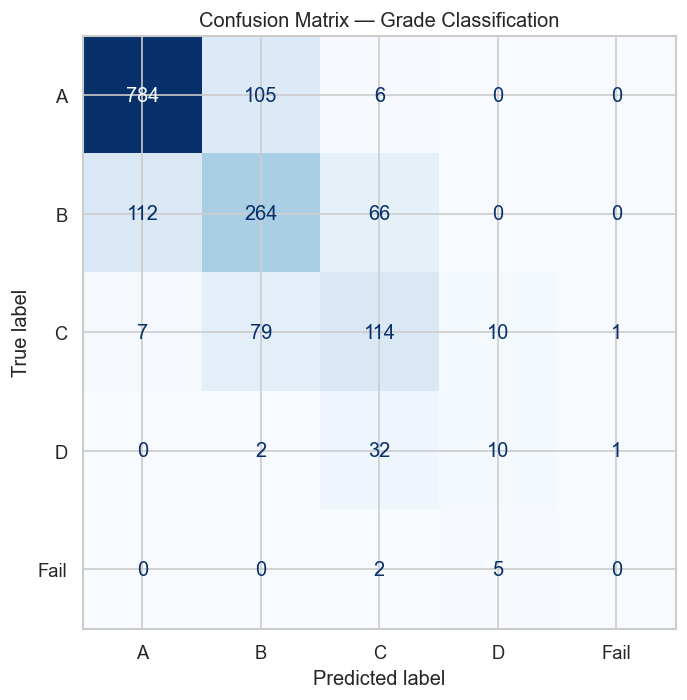

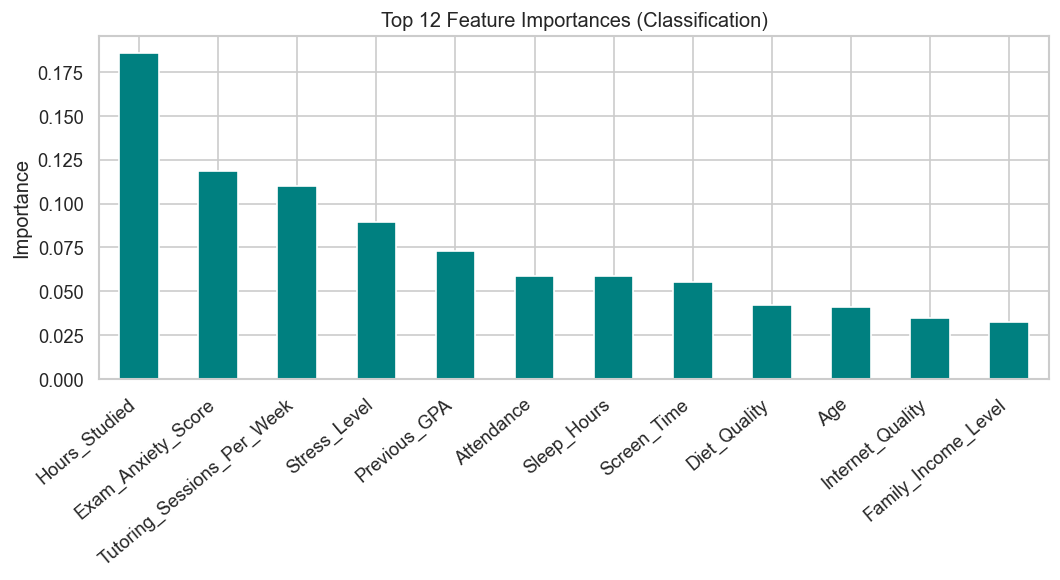


--- MODEL COMPARISON SUMMARY ---

Classification:
  Logistic Regression     CV F1: 0.7467 ± 0.0106
  K-Nearest Neighbors     CV F1: 0.6410 ± 0.0133
  Random Forest           CV F1: 0.7173 ± 0.0081
  Gradient Boosting       CV F1: 0.7199 ± 0.0121


In [17]:
# ============================================================
# STEP 5: Model Evaluation (Classification Only)
# ============================================================
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

y_clf_pred = best_clf_model.predict(X_clf_test)

grade_order = ['A', 'B', 'C', 'D', 'Fail']

print("\n" + "=" * 45)
print("CLASSIFICATION — Test Set Results")
print("=" * 45)
print(classification_report(y_clf_test, y_clf_pred, labels=grade_order, target_names=grade_order))

# Confusion matrix
cm = confusion_matrix(y_clf_test, y_clf_pred, labels=grade_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grade_order)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Grade Classification')
plt.tight_layout()
plt.savefig('eval_clf_confusion_matrix.png')
plt.show()

# Feature importance — Classification
feat_names = best_clf_model.named_steps['preprocess'].get_feature_names_out()
feat_names = [
    n.replace('num__', '').replace('ord__', '').replace('nom__', '').replace('bin__', '')
    for n in feat_names
 ]
importances_clf = best_clf_model.named_steps['model'].feature_importances_
feat_imp_clf = pd.Series(importances_clf, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
feat_imp_clf.head(12).plot(kind='bar', color='teal', edgecolor='white')
plt.title('Top 12 Feature Importances (Classification)')
plt.ylabel('Importance')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('eval_clf_feature_importance.png')
plt.show()

# Model comparison summary table
print("\n--- MODEL COMPARISON SUMMARY ---")
print("\nClassification:")
for name, r in clf_results.items():
    print(f"  {name:<22}  CV F1: {r['cv_f1_mean']:.4f} ± {r['cv_f1_std']:.4f}")

# Step 6 — Model deployment
Persist the classification model and preprocessor to disk, validate predictions with a sample input, and generate a simple Flask API for serving predictions.

In [18]:
# ============================================================
# STEP 6: Model Deployment (Classification Only)
# ============================================================
import joblib
import json

# ----------------------------------------------------------
# 6.1  Save the trained model pipeline
# ----------------------------------------------------------
joblib.dump(best_clf_model, 'model_classification.pkl')

print("Model pipeline saved!")

# ----------------------------------------------------------
# 6.2  Load and run a prediction (verify it works)
# ----------------------------------------------------------
loaded_clf_model = joblib.load('model_classification.pkl')

# Example new student record (use raw categorical values)
new_student = pd.DataFrame([{
    'Age':                        20,
    'Gender':                     'Male',
    'Hours_Studied':              6.5,
    'Attendance':                 85.0,
    'Sleep_Hours':                7.0,
    'Stress_Level':               3.5,
    'Screen_Time':                2.5,
    'Previous_GPA':               3.2,
    'Part_Time_Job':              'No',
    'Study_Method':               'Hybrid',
    'Diet_Quality':               'Good',
    'Internet_Quality':           'Good',
    'Extracurricular':            'Yes',
    'Tutoring_Sessions_Per_Week': 2,
    'Family_Income_Level':        'Middle',
    'Exam_Anxiety_Score':         4.0,
}])

predicted_grade = loaded_clf_model.predict(new_student)[0]
grade_proba     = loaded_clf_model.predict_proba(new_student)[0]
grade_classes   = loaded_clf_model.named_steps['model'].classes_

print(f"\nPredicted Grade       : {predicted_grade}")
print("\nGrade probabilities:")
for cls, prob in zip(grade_classes, grade_proba):
    print(f"  {cls}: {prob:.3f}")

Model pipeline saved!

Predicted Grade       : A

Grade probabilities:
  A: 0.981
  B: 0.019
  C: 0.000
  D: 0.000
  Fail: 0.000


In [ ]:
# ----------------------------------------------------------
# 6.3  Simple Flask API (save this as app.py — run separately)
# ----------------------------------------------------------

# Save this code block to a file called app.py
flask_code = '''
from flask import Flask, request, jsonify
import joblib, pandas as pd

app = Flask(__name__)

clf_model = joblib.load("model_classification.pkl")

@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json()
    df = pd.DataFrame([data])

    grade = clf_model.predict(df)[0]
    probs = clf_model.predict_proba(df)[0]
    classes = clf_model.named_steps['model'].classes_

    return jsonify({
        "predicted_grade": grade,
        "grade_probabilities": {c: float(p) for c, p in zip(classes, probs)}
    })

if __name__ == "__main__":
    app.run(debug=True)
'''

with open('app.py', 'w') as f:
    f.write(flask_code)

print("app.py saved!")
print("Run with:  python app.py")
print()
print("Then test with curl:")
print("""
curl -X POST http://127.0.0.1:5000/predict \\
     -H "Content-Type: application/json" \\
     -d '{
           "Age": 20, "Gender": "Male",
           "Hours_Studied": 6.5, "Attendance": 85,
           "Sleep_Hours": 7, "Stress_Level": 3.5,
           "Screen_Time": 2.5, "Previous_GPA": 3.2,
           "Part_Time_Job": "No", "Study_Method": "Hybrid",
           "Diet_Quality": "Good", "Internet_Quality": "Good",
           "Extracurricular": "Yes",
           "Tutoring_Sessions_Per_Week": 2,
           "Family_Income_Level": "Middle",
           "Exam_Anxiety_Score": 4.0
         }'
""")